In [2]:
3+5

8

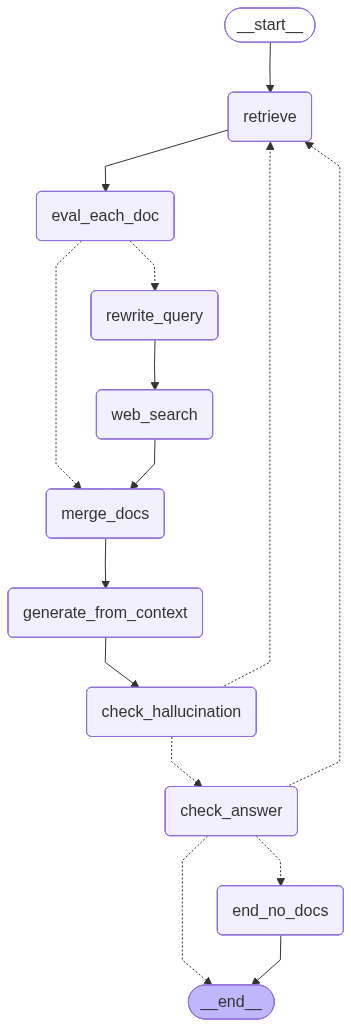

In [10]:
# =========================
# IMPORTS
# =========================
from typing import List, TypedDict
from pydantic import BaseModel

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.embeddings import Embeddings
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, START, END

import requests
import os
from dotenv import load_dotenv

load_dotenv()

# =========================
# CONSTANTS
# =========================
UPPER_TH       = 0.7
LOWER_TH       = 0.3
MAX_GENERATIONS = 2

# =========================
# LLM
# =========================
llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    temperature=0
)

# =========================
# EMBEDDINGS (JINA)
# =========================
JINA_API_KEY = os.getenv("JINA_API_KEY")

def get_embeddings_batch(texts):
    url = "https://api.jina.ai/v1/embeddings"
    headers = {
        "Authorization": f"Bearer {JINA_API_KEY}",
        "Content-Type": "application/json"
    }
    data = {"input": texts, "model": "jina-embeddings-v2-base-en"}
    response = requests.post(url, headers=headers, json=data)
    return [item["embedding"] for item in response.json()["data"]]

class JinaEmbeddings(Embeddings):
    def embed_documents(self, texts):
        return get_embeddings_batch(texts)
    def embed_query(self, text):
        return get_embeddings_batch([text])[0]

embedding = JinaEmbeddings()

# =========================
# LOAD + SPLIT DOCS
# =========================
PATH = r"C:\Projects\rag_project\Methodology_Paper.pdf"
documents = PyPDFLoader(PATH).load()

splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(documents)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8")

vector_store = FAISS.from_documents(chunks, embedding)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

# =========================
# STATE
# =========================
class State(TypedDict):
    question:         str
    top_docs:         List[Document]   # raw FAISS results
    verdict:          str              # CORRECT / INCORRECT / AMBIGUOUS
    reason:           str
    good_docs:        List[Document]   # docs that passed eval (score > LOWER_TH)
    web_query:        str
    web_docs:         List[Document]   # Tavily results
    refined_context:  str              # final merged context passed to LLM
    strips:           List[str]        # placeholder for sentence-level strips
    kept_strips:      List[str]        # placeholder for filtered strips
    answer:           str
    hallucination_ok: bool
    answer_ok:        bool
    generation_count: int

# =========================
# STRUCTURED OUTPUT MODELS
# =========================
class DocEvalScore(BaseModel):
    score:  float
    reason: str

class HallucinationDecision(BaseModel):
    is_grounded: bool

class AnswerDecision(BaseModel):
    is_useful: bool

class WebQuery(BaseModel):
    query: str

# =========================
# PROMPTS
# =========================
doc_eval_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a strict retrieval evaluator for RAG.\n"
     "You will be given ONE retrieved chunk and a question.\n"
     "Return a relevance score in [0.0, 1.0].\n"
     "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
     "- 0.0: chunk is irrelevant\n"
     "Be conservative with high scores.\n"
     "Also return a short reason.\n"
     "Output JSON only."),
    ("human", "Question: {question}\n\nChunk:\n{chunk}")
])
doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are checking if an answer is grounded in the provided context.\n"
     "Return ONLY JSON: {{\"is_grounded\": true/false}}"),
    ("human",
     "Context:\n{context}\n\n"
     "Answer:\n{answer}\n\n"
     "Is every claim in the answer supported by the context?")
])
hallucination_chain = hallucination_prompt | llm.with_structured_output(HallucinationDecision)

answer_check_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Judge if the answer fully resolves the question.\n"
     "Return ONLY JSON: {{\"is_useful\": true/false}}"),
    ("human",
     "Question:\n{question}\n\n"
     "Answer:\n{answer}\n\n"
     "Does this answer fully resolve the question?")
])
answer_check_chain = answer_check_prompt | llm.with_structured_output(AnswerDecision)

rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Rewrite the question into a concise web search query.\n"
     "Return ONLY JSON: {{\"query\": \"...\"}}"),
    ("human", "Question: {question}")
])
rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

rag_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Answer using ONLY the provided context.\n"
     "If there is not enough information, say: No relevant document found."),
    ("human", "Question:\n{question}\n\nContext:\n{context}")
])

# =========================
# 1. RETRIEVE
# =========================
def retrieve(state: State):
    print("Retrieving docs...")
    docs = retriever.invoke(state["question"])
    return {
        "top_docs":         docs,
        "web_docs":         [],
        "good_docs":        [],
        "generation_count": state.get("generation_count", 0),
    }

# =========================
# 2. EVAL EACH DOC
# =========================
def eval_each_doc(state: State) -> dict:
    print("Evaluating each doc...")
    q      = state["question"]
    scores: List[float] = []
    good:   List[Document] = []

    for d in state["top_docs"]:
        try:
            out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
            scores.append(out.score)
            if out.score > LOWER_TH:
                good.append(d)
        except Exception as e:
            print(f"Doc eval error: {e}")
            scores.append(0.0)

    if any(s > UPPER_TH for s in scores):
        print(f"Verdict: CORRECT")
        return {
            "good_docs": good,
            "verdict":   "CORRECT",
            "reason":    f"At least one chunk scored > {UPPER_TH}.",
        }

    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        print(f"Verdict: INCORRECT")
        return {
            "good_docs": [],
            "verdict":   "INCORRECT",
            "reason":    f"All chunks scored < {LOWER_TH}.",
        }

    print(f"Verdict: AMBIGUOUS")
    return {
        "good_docs": good,
        "verdict":   "AMBIGUOUS",
        "reason":    f"No chunk > {UPPER_TH}, but not all < {LOWER_TH}.",
    }

# =========================
# 3. REWRITE QUERY
# =========================
def rewrite_query(state: State):
    print("Rewriting query...")
    try:
        out   = rewrite_chain.invoke({"question": state["question"]})
        query = out.query
    except Exception:
        query = state["question"]
    return {"web_query": query}

# =========================
# 4. WEB SEARCH
# =========================
tavily = TavilySearchResults(max_results=5)

def web_search(state: State):
    print("Running web search...")
    query   = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": query})
    docs    = [
        Document(page_content=f"{r.get('title', '')}\n{r.get('content', '')}")
        for r in results
    ]
    return {"web_docs": docs}

# =========================
# 5. MERGE DOCS
# Three-way logic based on verdict
# =========================
def merge_docs(state: State):
    print(f"Merging docs (verdict={state.get('verdict')})...")
    verdict = state.get("verdict")

    if verdict == "CORRECT":
        docs_to_use = state.get("top_docs", [])
    elif verdict == "INCORRECT":
        docs_to_use = state.get("web_docs", [])
    else:  # AMBIGUOUS
        docs_to_use = state.get("top_docs", []) + state.get("web_docs", [])

    context = "\n\n---\n\n".join([d.page_content for d in docs_to_use])

    return {
        "good_docs":       docs_to_use,
        "refined_context": context,
        "strips":          [],       # placeholder
        "kept_strips":     [],       # placeholder
    }

# =========================
# 6. GENERATE FROM CONTEXT
# =========================
def generate_from_context(state: State):
    print("Generating answer...")
    context = state.get("refined_context", "")

    if not context.strip():
        return {
            "answer":           "No relevant document found.",
            "generation_count": state.get("generation_count", 0) + 1,
        }

    out = llm.invoke(rag_prompt.format_messages(
        question=state["question"],
        context=context
    ))
    return {
        "answer":           out.content,
        "generation_count": state.get("generation_count", 0) + 1,
    }

# =========================
# 7. HALLUCINATION CHECK
# =========================
def check_hallucination(state: State):
    print("Checking for hallucinations...")
    try:
        decision = hallucination_chain.invoke({
            "context": state.get("refined_context", ""),
            "answer":  state.get("answer", "")
        })
        return {"hallucination_ok": decision.is_grounded}
    except Exception as e:
        print(f"Hallucination check error: {e}")
        return {"hallucination_ok": True}

# =========================
# 8. ANSWER QUALITY CHECK
# =========================
def check_answer(state: State):
    print("Checking answer quality...")
    try:
        decision = answer_check_chain.invoke({
            "question": state["question"],
            "answer":   state.get("answer", "")
        })
        return {"answer_ok": decision.is_useful}
    except Exception as e:
        print(f"Answer check error: {e}")
        return {"answer_ok": True}

# =========================
# 9. GRACEFUL EXIT
# =========================
def end_no_docs(state: State):
    return {"answer": "I could not find relevant information in the document or on the web."}

# =========================
# ROUTERS
# =========================
def route_after_eval(state: State):
    # CORRECT → skip web search, go straight to merge
    if state.get("verdict") == "CORRECT":
        return "merge_docs"
    # INCORRECT or AMBIGUOUS → go get web results first
    return "rewrite_query"

def route_after_hallucination(state: State):
    if state.get("hallucination_ok", True):
        return "check_answer"
    if state.get("generation_count", 0) >= MAX_GENERATIONS:
        return "check_answer"   # accept best effort, stop retrying
    return "retrieve"

def route_after_answer_check(state: State):
    if state.get("answer_ok", True):
        return END
    if state.get("generation_count", 0) >= MAX_GENERATIONS:
        return "end_no_docs"              # best answer we have, stop here
    return "retrieve"

# =========================
# GRAPH
# =========================
g = StateGraph(State)

g.add_node("retrieve",             retrieve)
g.add_node("eval_each_doc",        eval_each_doc)
g.add_node("rewrite_query",        rewrite_query)
g.add_node("web_search",           web_search)
g.add_node("merge_docs",           merge_docs)
g.add_node("generate_from_context",generate_from_context)
g.add_node("check_hallucination",  check_hallucination)
g.add_node("check_answer",         check_answer)
g.add_node("end_no_docs",          end_no_docs)

g.add_edge(START,          "retrieve")
g.add_edge("retrieve",     "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc", route_after_eval,
    {
        "merge_docs":    "merge_docs",
        "rewrite_query": "rewrite_query",
    }
)

g.add_edge("rewrite_query",         "web_search")
g.add_edge("web_search",            "merge_docs")
g.add_edge("merge_docs",            "generate_from_context")
g.add_edge("generate_from_context", "check_hallucination")

g.add_conditional_edges(
    "check_hallucination", route_after_hallucination,
    {
        "check_answer": "check_answer",
        "retrieve":     "retrieve",
    }
)

g.add_conditional_edges(
    "check_answer", route_after_answer_check,
    {
        END:            END,
        "retrieve":     "retrieve",
        "end_no_docs":  "end_no_docs",
    }
)

g.add_edge("end_no_docs", END)

app = g.compile()

# =========================
# RUN
# =========================
app

In [9]:
result=app.invoke({
    "question": "What are the main contributions of the paper?"})
result['answer']

Retrieving docs...
Evaluating each doc...
Verdict: AMBIGUOUS
Rewriting query...
Running web search...
Merging docs (verdict=AMBIGUOUS)...
Generating answer...
Checking for hallucinations...
Retrieving docs...
Evaluating each doc...
Verdict: AMBIGUOUS
Rewriting query...
Running web search...
Merging docs (verdict=AMBIGUOUS)...
Generating answer...
Checking for hallucinations...
Checking answer quality...


'No relevant document found.'

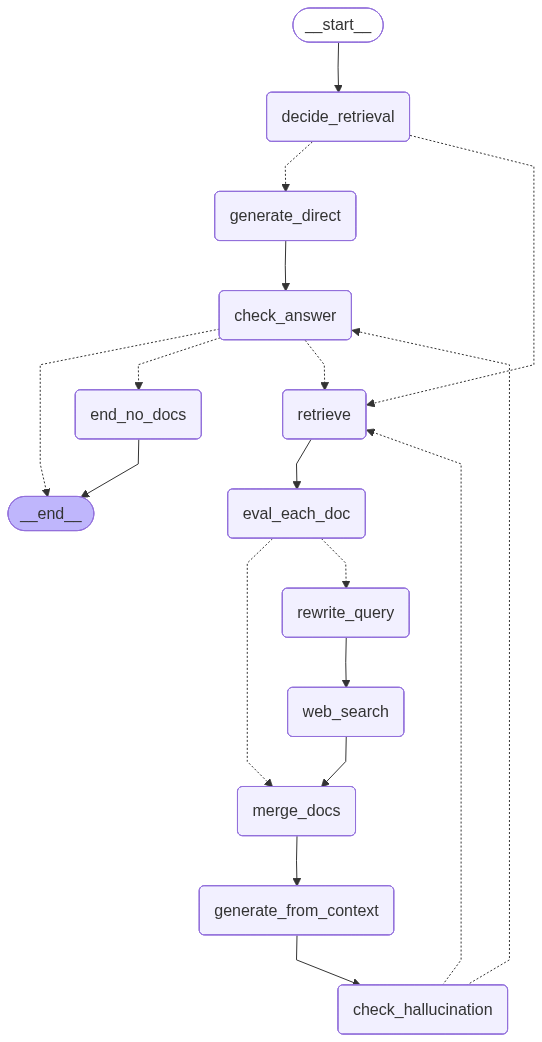

In [11]:
# =========================
# IMPORTS
# =========================
from typing import List, TypedDict
from pydantic import BaseModel

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.embeddings import Embeddings
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, START, END

import requests
import os
from dotenv import load_dotenv

load_dotenv()

# =========================
# CONSTANTS
# =========================
UPPER_TH        = 0.7
LOWER_TH        = 0.3
MAX_GENERATIONS = 2

# =========================
# LLM
# =========================
llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    temperature=0
)

# =========================
# EMBEDDINGS (JINA)
# =========================
JINA_API_KEY = os.getenv("JINA_API_KEY")

def get_embeddings_batch(texts):
    url = "https://api.jina.ai/v1/embeddings"
    headers = {
        "Authorization": f"Bearer {JINA_API_KEY}",
        "Content-Type": "application/json"
    }
    data = {"input": texts, "model": "jina-embeddings-v2-base-en"}
    response = requests.post(url, headers=headers, json=data)
    return [item["embedding"] for item in response.json()["data"]]

class JinaEmbeddings(Embeddings):
    def embed_documents(self, texts):
        return get_embeddings_batch(texts)
    def embed_query(self, text):
        return get_embeddings_batch([text])[0]

embedding = JinaEmbeddings()

# =========================
# LOAD + SPLIT DOCS
# =========================
PATH = r"C:\Projects\rag_project\Methodology_Paper.pdf"
documents = PyPDFLoader(PATH).load()

splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(documents)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8")

vector_store = FAISS.from_documents(chunks, embedding)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

# =========================
# STATE
# =========================
class State(TypedDict):
    question:         str
    need_retrieval:   bool             # NEW — set by decide_retrieval
    top_docs:         List[Document]
    verdict:          str              # CORRECT / INCORRECT / AMBIGUOUS
    reason:           str
    good_docs:        List[Document]
    web_query:        str
    web_docs:         List[Document]
    refined_context:  str
    strips:           List[str]
    kept_strips:      List[str]
    answer:           str
    hallucination_ok: bool
    answer_ok:        bool
    generation_count: int

# =========================
# STRUCTURED OUTPUT MODELS
# =========================
class RetrieveDecision(BaseModel):
    should_retrieve: bool
    reason: str

class DocEvalScore(BaseModel):
    score:  float
    reason: str

class HallucinationDecision(BaseModel):
    is_grounded: bool

class AnswerDecision(BaseModel):
    is_useful: bool

class WebQuery(BaseModel):
    query: str

# =========================
# PROMPTS
# =========================
decide_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are deciding whether a question requires retrieving documents from a research paper.\n"
     "Return {{\"should_retrieve\": true}} if the question is about the paper's content "
     "(methodology, findings, abstract, results, authors, etc.).\n"
     "Return {{\"should_retrieve\": false}} if the question is general knowledge "
     "that does not need the paper at all (e.g. 'what is machine learning').\n"
     "Also return a short reason.\n"
     "Output JSON only."),
    ("human", "Question: {question}")
])
decide_chain = decide_prompt | llm.with_structured_output(RetrieveDecision)

doc_eval_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are a strict retrieval evaluator for RAG.\n"
     "You will be given ONE retrieved chunk and a question.\n"
     "Return a relevance score in [0.0, 1.0].\n"
     "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
     "- 0.0: chunk is irrelevant\n"
     "Be conservative with high scores.\n"
     "Also return a short reason.\n"
     "Output JSON only."),
    ("human", "Question: {question}\n\nChunk:\n{chunk}")
])
doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

hallucination_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are checking if an answer is grounded in the provided context.\n"
     "Return ONLY JSON: {{\"is_grounded\": true/false}}"),
    ("human",
     "Context:\n{context}\n\n"
     "Answer:\n{answer}\n\n"
     "Is every claim in the answer supported by the context?")
])
hallucination_chain = hallucination_prompt | llm.with_structured_output(HallucinationDecision)

answer_check_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Judge if the answer fully resolves the question.\n"
     "Return ONLY JSON: {{\"is_useful\": true/false}}"),
    ("human",
     "Question:\n{question}\n\n"
     "Answer:\n{answer}\n\n"
     "Does this answer fully resolve the question?")
])
answer_check_chain = answer_check_prompt | llm.with_structured_output(AnswerDecision)

rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Rewrite the question into a concise web search query.\n"
     "Return ONLY JSON: {{\"query\": \"...\"}}"),
    ("human", "Question: {question}")
])
rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

rag_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Answer using ONLY the provided context.\n"
     "If there is not enough information, say: No relevant document found."),
    ("human", "Question:\n{question}\n\nContext:\n{context}")
])

direct_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Answer the question using your general knowledge.\n"
     "If you are unsure, say you don't know."),
    ("human", "{question}")
])

# =========================
# 0. DECIDE RETRIEVAL  (NEW)
# =========================
def decide_retrieval(state: State):
    print("Deciding whether retrieval is needed...")
    try:
        out = decide_chain.invoke({"question": state["question"]})
        print(f"  → should_retrieve={out.should_retrieve} | {out.reason}")
        return {
            "need_retrieval":   out.should_retrieve,
            "generation_count": 0,
        }
    except Exception as e:
        print(f"Decide retrieval error: {e} — defaulting to retrieve=True")
        return {
            "need_retrieval":   True,
            "generation_count": 0,
        }

# =========================
# 1. RETRIEVE
# =========================
def retrieve(state: State):
    print("Retrieving docs...")
    docs = retriever.invoke(state["question"])
    return {
        "top_docs":  docs,
        "web_docs":  [],
        "good_docs": [],
    }

# =========================
# 2. EVAL EACH DOC
# =========================
def eval_each_doc(state: State) -> dict:
    print("Evaluating each doc...")
    q      = state["question"]
    scores: List[float]    = []
    good:   List[Document] = []

    for d in state["top_docs"]:
        try:
            out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
            scores.append(out.score)
            if out.score > LOWER_TH:
                good.append(d)
        except Exception as e:
            print(f"Doc eval error: {e}")
            scores.append(0.0)

    if any(s > UPPER_TH for s in scores):
        print("Verdict: CORRECT")
        return {
            "good_docs": good,
            "verdict":   "CORRECT",
            "reason":    f"At least one chunk scored > {UPPER_TH}.",
        }

    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        print("Verdict: INCORRECT")
        return {
            "good_docs": [],
            "verdict":   "INCORRECT",
            "reason":    f"All chunks scored < {LOWER_TH}.",
        }

    print("Verdict: AMBIGUOUS")
    return {
        "good_docs": good,
        "verdict":   "AMBIGUOUS",
        "reason":    f"No chunk > {UPPER_TH}, but not all < {LOWER_TH}.",
    }

# =========================
# 3. REWRITE QUERY
# =========================
def rewrite_query(state: State):
    print("Rewriting query...")
    try:
        out   = rewrite_chain.invoke({"question": state["question"]})
        query = out.query
    except Exception:
        query = state["question"]
    return {"web_query": query}

# =========================
# 4. WEB SEARCH
# =========================
tavily = TavilySearchResults(max_results=5)

def web_search(state: State):
    print("Running web search...")
    query   = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": query})
    docs    = [
        Document(page_content=f"{r.get('title', '')}\n{r.get('content', '')}")
        for r in results
    ]
    return {"web_docs": docs}

# =========================
# 5. MERGE DOCS
# =========================
def merge_docs(state: State):
    print(f"Merging docs (verdict={state.get('verdict')})...")
    verdict = state.get("verdict")

    if verdict == "CORRECT":
        docs_to_use = state.get("top_docs", [])
    elif verdict == "INCORRECT":
        docs_to_use = state.get("web_docs", [])
    else:  # AMBIGUOUS
        docs_to_use = state.get("top_docs", []) + state.get("web_docs", [])

    context = "\n\n---\n\n".join([d.page_content for d in docs_to_use])

    return {
        "good_docs":       docs_to_use,
        "refined_context": context,
        "strips":          [],
        "kept_strips":     [],
    }

# =========================
# 6. GENERATE FROM CONTEXT
# =========================
def generate_from_context(state: State):
    print("Generating answer from context...")
    context = state.get("refined_context", "")

    if not context.strip():
        return {
            "answer":           "No relevant document found.",
            "generation_count": state.get("generation_count", 0) + 1,
        }

    out = llm.invoke(rag_prompt.format_messages(
        question=state["question"],
        context=context
    ))
    return {
        "answer":           out.content,
        "generation_count": state.get("generation_count", 0) + 1,
    }

# =========================
# 6b. DIRECT GENERATION  (NEW — no retrieval path)
# =========================
def generate_direct(state: State):
    print("Generating answer directly (no retrieval)...")
    out = llm.invoke(direct_prompt.format_messages(question=state["question"]))
    return {
        "answer":           out.content,
        "generation_count": state.get("generation_count", 0) + 1,
        "refined_context":  "",   # no context on this path
    }

# =========================
# 7. HALLUCINATION CHECK
# =========================
def check_hallucination(state: State):
    print("Checking for hallucinations...")
    # If there is no context (direct generation path) skip this check
    context = state.get("refined_context", "")
    if not context.strip():
        print("  → No context present, skipping hallucination check.")
        return {"hallucination_ok": True}
    try:
        decision = hallucination_chain.invoke({
            "context": context,
            "answer":  state.get("answer", "")
        })
        return {"hallucination_ok": decision.is_grounded}
    except Exception as e:
        print(f"Hallucination check error: {e}")
        return {"hallucination_ok": True}

# =========================
# 8. ANSWER QUALITY CHECK
# =========================
def check_answer(state: State):
    print("Checking answer quality...")
    try:
        decision = answer_check_chain.invoke({
            "question": state["question"],
            "answer":   state.get("answer", "")
        })
        return {"answer_ok": decision.is_useful}
    except Exception as e:
        print(f"Answer check error: {e}")
        return {"answer_ok": True}

# =========================
# 9. GRACEFUL EXIT
# =========================
def end_no_docs(state: State):
    return {"answer": "I could not find relevant information in the document or on the web."}

# =========================
# ROUTERS
# =========================
def route_after_decide(state: State):
    return "retrieve" if state.get("need_retrieval") else "generate_direct"

def route_after_eval(state: State):
    if state.get("verdict") == "CORRECT":
        return "merge_docs"
    return "rewrite_query"

def route_after_hallucination(state: State):
    if not state.get("hallucination_ok", True):
        if state.get("generation_count", 0) >= MAX_GENERATIONS:
            return "check_answer"   # cap hit — accept and move on
        return "retrieve"
    return "check_answer"

def route_after_answer_check(state: State):
    if state.get("answer_ok", True):
        return END
    if state.get("generation_count", 0) >= MAX_GENERATIONS:
        return "end_no_docs"
    # If we came from the direct path, retry with retrieval this time
    return "retrieve"

# =========================
# GRAPH
# =========================
g = StateGraph(State)

g.add_node("decide_retrieval",      decide_retrieval)
g.add_node("retrieve",              retrieve)
g.add_node("eval_each_doc",         eval_each_doc)
g.add_node("rewrite_query",         rewrite_query)
g.add_node("web_search",            web_search)
g.add_node("merge_docs",            merge_docs)
g.add_node("generate_direct",       generate_direct)
g.add_node("generate_from_context", generate_from_context)
g.add_node("check_hallucination",   check_hallucination)
g.add_node("check_answer",          check_answer)
g.add_node("end_no_docs",           end_no_docs)

# Entry
g.add_edge(START, "decide_retrieval")

# Decide → two paths
g.add_conditional_edges(
    "decide_retrieval", route_after_decide,
    {
        "retrieve":        "retrieve",
        "generate_direct": "generate_direct",
    }
)

# Retrieval path
g.add_edge("retrieve",     "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc", route_after_eval,
    {
        "merge_docs":    "merge_docs",
        "rewrite_query": "rewrite_query",
    }
)

g.add_edge("rewrite_query",         "web_search")
g.add_edge("web_search",            "merge_docs")
g.add_edge("merge_docs",            "generate_from_context")
g.add_edge("generate_from_context", "check_hallucination")

g.add_conditional_edges(
    "check_hallucination", route_after_hallucination,
    {
        "check_answer": "check_answer",
        "retrieve":     "retrieve",
    }
)

# Direct path joins the graph here — both paths meet at check_answer
g.add_edge("generate_direct", "check_answer")

g.add_conditional_edges(
    "check_answer", route_after_answer_check,
    {
        END:           END,
        "retrieve":    "retrieve",
        "end_no_docs": "end_no_docs",
    }
)

g.add_edge("end_no_docs", END)

app = g.compile()

# =========================
# RUN
# =========================
app

In [12]:
# =========================
# IMPORTS
# =========================
from typing import List
from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.embeddings import Embeddings
from langchain_community.retrievers import BM25Retriever

import requests
import os
from dotenv import load_dotenv

load_dotenv()

# =========================
# CONFIG
# =========================
TOP_K = 3

# =========================
# LLM (your OpenRouter)
# =========================
llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    base_url="https://openrouter.ai/api/v1",
    temperature=0
)

# =========================
# JINA EMBEDDINGS
# =========================
JINA_API_KEY = os.getenv("JINA_API_KEY")

def get_embeddings_batch(texts):
    url = "https://api.jina.ai/v1/embeddings"
    headers = {
        "Authorization": f"Bearer {JINA_API_KEY}",
        "Content-Type": "application/json"
    }
    data = {"input": texts, "model": "jina-embeddings-v2-base-en"}
    response = requests.post(url, headers=headers, json=data)
    return [item["embedding"] for item in response.json()["data"]]

class JinaEmbeddings(Embeddings):
    def embed_documents(self, texts):
        return get_embeddings_batch(texts)
    def embed_query(self, text):
        return get_embeddings_batch([text])[0]

embedding = JinaEmbeddings()

# =========================
# LOAD + SPLIT
# =========================
PATH = r"C:\Projects\rag_project\Methodology_Paper.pdf"

documents = PyPDFLoader(PATH).load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=150
)
chunks = splitter.split_documents(documents)

# Clean text
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8")

# =========================
# DENSE RETRIEVER (FAISS)
# =========================
faiss_store = FAISS.from_documents(chunks, embedding)
dense_retriever = faiss_store.as_retriever(search_kwargs={"k": 6})

# =========================
# SPARSE RETRIEVER (BM25)
# =========================
bm25_retriever = BM25Retriever.from_documents(chunks)
bm25_retriever.k = 6

# =========================
# RERANK PROMPT
# =========================
rerank_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "You are ranking documents for relevance.\n"
     "Score each document from 0 to 10.\n"
     "Return only the score."),
    ("human",
     "Question: {question}\n\nDocument:\n{doc}")
])

def rerank_docs(question: str, docs: List[Document]) -> List[Document]:
    scored = []

    for d in docs:
        try:
            msg = rerank_prompt.format_messages(
                question=question,
                doc=d.page_content[:1500]
            )
            score = llm.invoke(msg).content.strip()
            score = float(score)
        except:
            score = 0

        scored.append((score, d))

    # Sort by score descending
    scored.sort(key=lambda x: x[0], reverse=True)

    return [d for _, d in scored[:TOP_K]]

# =========================
# HYBRID RETRIEVAL
# =========================
def hybrid_retrieve(query: str) -> List[Document]:
    print("Running Hybrid Retrieval...")

    dense_docs = dense_retriever.invoke(query)
    sparse_docs = bm25_retriever.invoke(query)

    # Combine
    all_docs = dense_docs + sparse_docs

    # Deduplicate (based on content)
    seen = set()
    unique_docs = []
    for d in all_docs:
        if d.page_content not in seen:
            unique_docs.append(d)
            seen.add(d.page_content)

    print(f"Retrieved {len(unique_docs)} unique docs")

    # Rerank
    top_docs = rerank_docs(query, unique_docs)

    print(f"Top {len(top_docs)} docs selected")

    return top_docs

# =========================
# GENERATION
# =========================
rag_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Answer ONLY from the context.\n"
     "If not found, say: No relevant document found."),
    ("human",
     "Question: {question}\n\nContext:\n{context}")
])

def generate_answer(question: str, docs: List[Document]):
    context = "\n\n---\n\n".join([d.page_content for d in docs])

    if not context.strip():
        return "No relevant document found."

    response = llm.invoke(
        rag_prompt.format_messages(
            question=question,
            context=context
        )
    )

    return response.content

# =========================
# MAIN PIPELINE
# =========================
def ask(question: str):
    docs = hybrid_retrieve(question)
    answer = generate_answer(question, docs)
    return answer

# =========================
# TEST
# =========================
if __name__ == "__main__":
    q = "What is the methodology used in the paper?"
    print(ask(q))

ImportError: Could not import rank_bm25, please install with `pip install rank_bm25`.

In [13]:
pip install rank_bm25

Note: you may need to restart the kernel to use updated packages.
